# Chua's Circuit: part 2
Redo everything from scarch, using ONLY PEM UDE x

In [1]:
from scipy.integrate import solve_ivp 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import torch 
from torch import nn 
from torchdiffeq import odeint
import pysindy as ps 
from sr3_modified import my_SR3 as MySR3

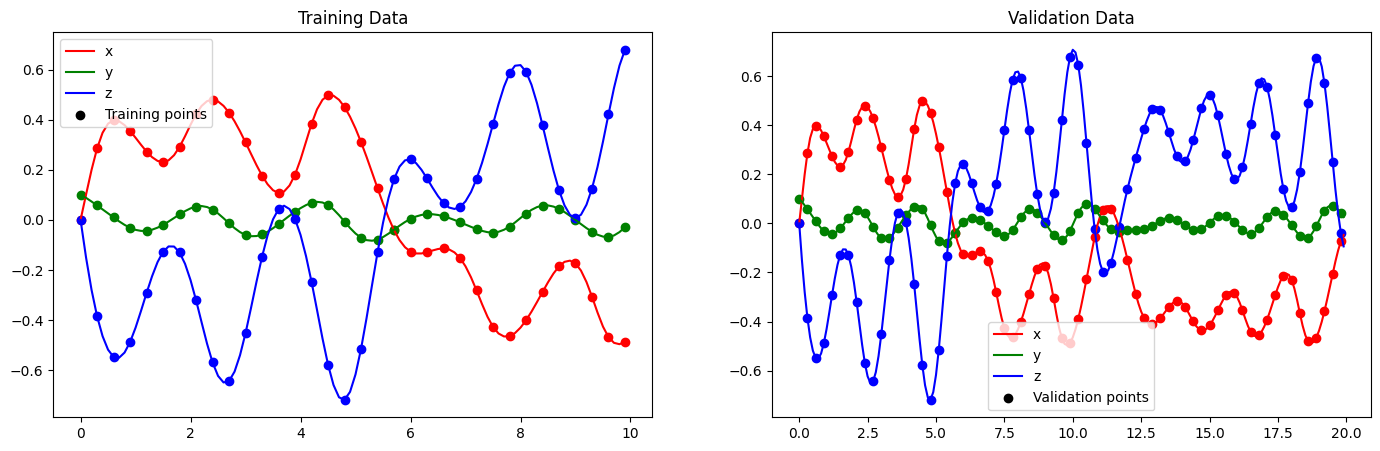

In [2]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, alpha, beta, gamma, a, c):
    x,y,z = xyz 
    return np.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

# 1: TRAINING DATA
plt.sca(axes[0])

T_MAX = 10
delta_t = 3

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0.0001, 0.1, 0), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)
data_train = sol.y.T[::delta_t, :]
t_train = sol.t[::delta_t]

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, sol.y[i, :], color=col, label=var_dict[i])
    plt.scatter(t_train, data_train[:, i], color=col)

plt.scatter([], [], color="k", label="Training points")

plt.title("Training Data")

plt.legend()

# 2: VAL DATA
plt.sca(axes[1])

T_MAX = 20.
delta_t = 3

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0.0001, 0.1, 0.0001), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

data_val = sol.y.T[::delta_t, :]
t_val = sol.t[::delta_t]

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, sol.y[i, :], color=col, label=var_dict[i])
    plt.scatter(t_val, data_val[:, i], color=col)

plt.scatter([], [], color="k", label="Validation points")

plt.title("Validation Data")

plt.legend()

plt.show()

# convert data to torch
torch_dtype = torch.float32

t_train_torch = torch.tensor(t_train, dtype=torch_dtype) 
t_val_torch = torch.tensor(t_val, dtype=torch_dtype)
data_train_torch = torch.tensor(data_train, dtype=torch_dtype, requires_grad=True)
data_val_troch = torch.tensor(data_val, dtype=torch_dtype, requires_grad=True)

In [24]:
def train_ude(T_train, X_train, T_val, X_val, ude: nn.Module, n_epochs: int, lr: float, verbose: bool = False, solver="rk4"):
    print("Training model...")
    x0_train = X_train[0, :].clone().detach()
    x0_val = X_val[0, :].clone().detach()

    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(ude.parameters(), lr)

    for EPOCH in range(0, n_epochs):
        optimizer.zero_grad()

        # get forward solution
        x_pred = odeint(ude, x0_train, T_train, method=solver, rtol=1e-12, atol=1e-12)

        loss = torch.mean((x_pred-X_train)**2)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if EPOCH % 100 == 0:
            with torch.no_grad():
                x_pred = odeint(ude, x0_val, T_val, method=solver, rtol=1e-12, atol=1e-12)
                val_loss = torch.mean((x_pred-X_val)**2)
                val_losses.append(val_loss.item())

        if verbose:
            if EPOCH % 100 == 0:
                print(f"{EPOCH}\t{loss:.4e}\t{val_loss:.4e}")
            else:
                print(f"{EPOCH}\t{loss:.4e}")
        

    return train_losses, val_losses

In [25]:
def batched_solve_and_evaluate(ude, X, T, method = 'dopri5', args = None):
    loss = torch.tensor(0.0, requires_grad=True)

    x0_i = X[0, :].clone().detach()

    for i in range(len(T)-1):
        x_pred = odeint(ude, x0_i, T[i:i+2], method=method, options=args)
        loss = loss + (torch.sum((x_pred - X[i+1]) ** 2, dim=1)).mean()
        x0_i = x_pred[-1]

    loss = loss/len(T)


    return loss 

def train_ude_alt(T_train, X_train, T_val, X_val, ude: nn.Module, n_epochs: int, lr: float, verbose: bool = False, solver='dopri5'):
    print("Training model...")

    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(ude.parameters(), lr)

    for EPOCH in range(0, n_epochs):
        optimizer.zero_grad()

        # get forward solution
        loss = batched_solve_and_evaluate(ude, X_train, T_train, method=solver)

        loss.backward()
        optimizer.step()

        if EPOCH % 100 == 0:
            with torch.no_grad():
                val_loss = batched_solve_and_evaluate(ude, X_val, T_val, method=solver)
                val_losses.append(val_loss.item())
            
        train_losses.append(loss.item())

        if verbose:
            if EPOCH % 100 == 0:
                print(f"{EPOCH}\t{loss:.4e}\t{val_loss:.4e}")
            else:
                print(f"{EPOCH}\t{loss:.4e}")
        

    return train_losses, val_losses

In [30]:

class PEM_ude_chua_x(nn.Module):
    def __init__(self, alpha, beta, gamma, K, obs_fn):
        super().__init__()

        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Dropout(),
            nn.Linear(64, 1),
        )

        with torch.no_grad():
            self.net[-1].weight.zero_()
            self.net[-1].bias.zero_()

        self.obs_fn = obs_fn
        self.register_buffer("K", torch.tensor(K, dtype=torch_dtype))

    def forward(self, t, data):
        x, y, z = data

        gx = self.net(x.reshape(1)).squeeze()

        dx = self.alpha * (y - gx)
        dy = x - y + z
        dz = -self.beta * y - self.gamma * z

        y_hat = self.obs_fn(t).to(data) # obs

        ex = y_hat[0] - x
        ey = y_hat[1] - y
        ez = y_hat[2] - z

        dx = dx + self.K[0] * ex
        dy = dy + self.K[1] * ey
        dz = dz + self.K[2] * ez

        return torch.stack([dx, dy, dz])
    
class LinearInterpolator:
    def __init__(self, t_obs, y_obs):
        # t_obs: (N,)
        # y_obs: (N, 3)
        self.t_obs = t_obs
        self.y_obs = y_obs

    def __call__(self, t):
        # assumes scalar t tensor
        idx = torch.searchsorted(self.t_obs, t.clamp(self.t_obs[0], self.t_obs[-1]))
        idx = torch.clamp(idx, 1, len(self.t_obs) - 1)

        t0 = self.t_obs[idx - 1]
        t1 = self.t_obs[idx]
        y0 = self.y_obs[idx - 1]
        y1 = self.y_obs[idx]

        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1 - w) * y0 + w * y1

In [31]:
pem_model_x = PEM_ude_chua_x(ALPHA, BETA, GAMMA, (0.3, 0.3, 0.3), LinearInterpolator(t_train_torch, data_train_torch))
losses_train_pemx, losses_val_pemx = train_ude(t_train_torch, data_train_torch, t_val_torch, data_val_troch, pem_model_x, 301, 0.001, True, solver='rk4')

Training model...
0	4.7445e-02	5.6065e+00
1	4.6002e-02
2	4.5321e-02
3	3.9963e-02
4	4.1739e-02
5	4.3129e-02
6	4.1613e-02
7	4.0224e-02
8	3.9994e-02
9	4.1268e-02
10	4.1815e-02
11	4.0805e-02
12	4.0178e-02
13	3.9625e-02
14	4.0969e-02
15	4.1066e-02
16	4.0183e-02
17	3.9953e-02
18	3.9906e-02
19	4.0045e-02
20	3.9602e-02
21	3.9893e-02
22	3.9964e-02
23	3.9836e-02
24	3.9973e-02
25	4.0032e-02
26	3.9710e-02
27	3.9743e-02
28	3.9655e-02
29	3.9084e-02
30	3.9851e-02
31	3.9385e-02
32	3.8976e-02
33	3.9464e-02
34	3.9386e-02
35	3.9174e-02
36	3.8275e-02
37	3.8389e-02
38	3.8207e-02
39	3.8639e-02
40	3.8105e-02
41	3.7841e-02
42	3.8281e-02
43	3.6920e-02
44	3.6693e-02
45	3.4577e-02
46	3.5824e-02
47	3.8605e-02
48	5.7385e-02
49	3.6274e-02
50	4.9469e-02
51	4.0618e-02
52	3.7681e-02
53	3.9286e-02
54	4.0839e-02
55	3.9157e-02
56	3.8781e-02
57	3.8130e-02
58	3.8418e-02
59	3.9516e-02
60	3.9454e-02
61	3.9442e-02
62	3.8658e-02
63	3.8508e-02
64	3.9091e-02
65	3.8624e-02
66	3.9529e-02
67	3.9024e-02
68	3.8239e-02
69	3.7862e-02
7

In [32]:
losses_train_pemx2, losses_val_pemx2 = train_ude(t_train_torch, data_train_torch, t_val_torch, data_val_troch, pem_model_x, 1001, 0.0001, True, solver='rk4')

Training model...
0	3.7497e-02	1.1894e+01
1	3.7205e-02
2	3.7650e-02
3	3.7280e-02
4	3.6906e-02
5	3.6967e-02
6	3.6441e-02
7	3.6276e-02
8	3.7000e-02
9	3.6330e-02
10	3.6663e-02
11	3.6550e-02
12	3.6152e-02
13	3.7538e-02
14	3.5895e-02
15	3.6064e-02
16	3.4935e-02
17	3.5201e-02
18	3.6358e-02
19	3.5816e-02
20	3.5421e-02
21	3.4699e-02
22	3.5853e-02
23	3.6158e-02
24	3.6604e-02
25	3.5984e-02
26	3.5341e-02
27	3.6099e-02
28	3.6020e-02
29	3.5410e-02
30	3.6144e-02
31	3.5327e-02
32	3.5961e-02
33	3.5419e-02
34	3.4012e-02
35	3.6411e-02
36	3.5262e-02
37	3.6152e-02
38	3.6313e-02
39	3.5098e-02
40	3.4385e-02
41	3.6761e-02
42	3.5616e-02
43	3.5183e-02
44	3.4523e-02
45	3.5620e-02
46	3.5701e-02
47	3.5809e-02
48	3.6175e-02
49	3.6862e-02
50	3.5125e-02
51	3.5141e-02
52	3.6146e-02
53	3.4905e-02
54	3.5915e-02
55	3.5584e-02
56	3.5416e-02
57	3.3985e-02
58	3.8649e-02
59	3.6921e-02
60	3.5889e-02
61	3.4441e-02
62	3.6134e-02
63	3.5237e-02
64	3.6408e-02
65	3.5805e-02
66	3.6195e-02
67	3.5601e-02
68	3.5078e-02
69	3.5285e-02
7

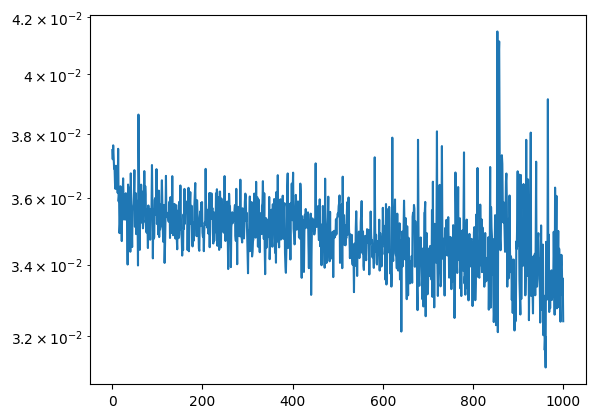

In [33]:
plt.semilogy(losses_train_pemx2)

In [34]:
# Considering trying to do this with Julia; unfortunately torchdiffeq doesn't support stiff solvers...